In [1]:
# menghubungkan colab dengan google drive
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, RocCurveDisplay, ConfusionMatrixDisplay
)

In [6]:

# memanggil data set lewat gdrive
path = "/content/gdrive/MyDrive/Praktikum_ML/pertemuan-4"

# membaca file csv menggunakan pandas
import pandas as pd
df = pd.read_csv("/content/gdrive/MyDrive/Praktikum_ML/Praktikum04/Data/calonpembelimobil.csv")
df.head()

,ID,Usia,Status,Kelamin,Memiliki_Mobil,Penghasilan,Beli_Mobil
0,1,32,1,0,0,240,1
1,2,49,2,1,1,100,0
2,3,52,1,0,2,250,1
3,4,26,2,1,1,130,0
4,5,45,3,0,2,237,1


In [7]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   ID              1000 non-null   int64
 1   Usia            1000 non-null   int64
 2   Status          1000 non-null   int64
 3   Kelamin         1000 non-null   int64
 4   Memiliki_Mobil  1000 non-null   int64
 5   Penghasilan     1000 non-null   int64
 6   Beli_Mobil      1000 non-null   int64
dtypes: int64(7)
memory usage: 54.8 KB


In [8]:
# cek missing value
df.isnull().sum()

,0
ID,0
Usia,0
Status,0
Kelamin,0
Memiliki_Mobil,0
Penghasilan,0
Beli_Mobil,0


In [9]:
# cek duplikat data
df.duplicated().sum()

np.int64(0)

In [10]:

# hapus data duplikat
df = df.drop_duplicates()

In [12]:
# cek nilai unik
df['Beli_Mobil'].unique()

array([1, 0])

In [14]:
# cek nilai unik
df['Kelamin'].unique()

array([0, 1])

In [16]:
# mapping kolom kategorik ke bentuk numerik
# 2. mapping kolom jenis kelamin -> biner
# laki-laki = 1, perempuan = 0
df['Kelamin_bin'] = (df['Kelamin'] == 1).astype(int) # Assuming 1 represents Laki-laki based on previous unique values check

print("\nDistribusi Kelamin_bin:\n", df['Kelamin_bin'].value_counts())


Distribusi Kelamin_bin:
 Kelamin_bin
0    519
1    481
Name: count, dtype: int64


In [17]:
corr_matrix = df.corr(numeric_only=True)
corr_matrix

,ID,Usia,Status,Kelamin,Memiliki_Mobil,Penghasilan,Beli_Mobil,Kelamin_bin
ID,1.000000,0.149779,-0.006634,0.014646,0.068555,0.254177,0.168614,0.014646
Usia,0.149779,1.000000,0.051476,0.019454,0.090926,0.125859,0.100127,0.019454
Status,-0.006634,0.051476,1.000000,-0.008561,0.048302,0.071714,0.048584,-0.008561
Kelamin,0.014646,0.019454,-0.008561,1.000000,0.035199,-0.054211,-0.147301,1.000000
Memiliki_Mobil,0.068555,0.090926,0.048302,0.035199,1.000000,0.137823,0.102005,0.035199
Penghasilan,0.254177,0.125859,0.071714,-0.054211,0.137823,1.000000,0.763930,-0.054211
Beli_Mobil,0.168614,0.100127,0.048584,-0.147301,0.102005,0.763930,1.000000,-0.147301
Kelamin_bin,0.014646,0.019454,-0.008561,1.000000,0.035199,-0.054211,-0.147301,1.000000


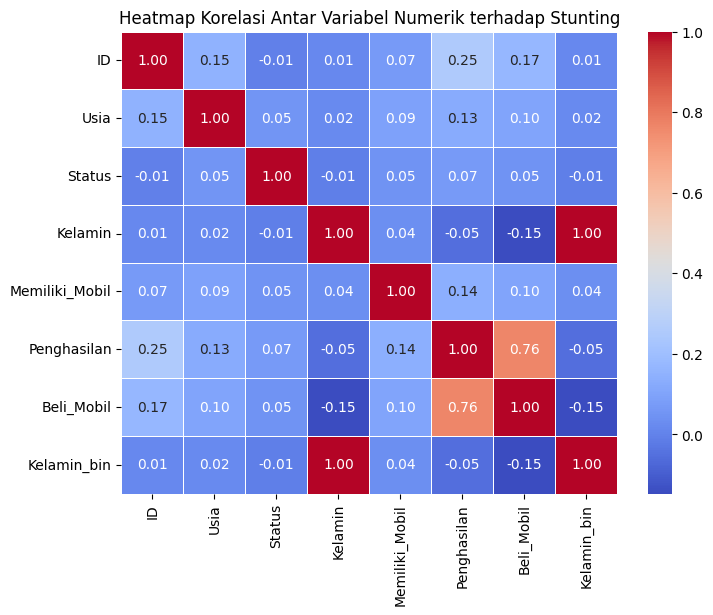

In [18]:
# visualisasi heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Heatmap Korelasi Antar Variabel Numerik terhadap Stunting", fontsize=12)
plt.show()

In [20]:
# Define features and target based on available columns
feature_num = ['Usia', 'Memiliki_Mobil', 'Penghasilan']
feature_cat = ['Status'] # Assuming 'Status' is categorical based on previous analysis, if not, move to feature_num
feature_bin = ['Kelamin_bin'] # Use the created binary column

# Combine features for X and define target y
use_cols_X = feature_num + feature_cat + feature_bin
use_col_y = 'Beli_Mobil'

df_model = df[use_cols_X + [use_col_y]].dropna().copy()

x = df_model[use_cols_X]
y = df_model [use_col_y]

print("x shape:", x.shape)
print("y shape:", y.shape)

x shape: (1000, 5)
y shape: (1000,)


In [21]:

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

print("Data latih:", x_train.shape)
print("Data uji:", x_test.shape)

Data latih: (800, 5)
Data uji: (200, 5)


In [22]:
# scale hanya fitur numerik, gender langsung passthrough
preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), feature_num),
        ('bin', 'passthrough', feature_bin)
    ],
    remainder='drop'
)
model = LogisticRegression(
    max_iter=1000,
    solver='lbfgs',
    class_weight='balanced',
    random_state=42
)
clf = Pipeline([
    ('preprocess', preprocess),
    ('model', model)
])
# latih model
clf.fit(x_train, y_train)
print("✅ Model Logistic Regression berhasil dilatih")

✅ Model Logistic Regression berhasil dilatih


In [23]:
# prediksi dan probabilitas
y_pred = clf.predict(x_test)
y_prob = clf.predict_proba(x_test)[:, 1]

# hitung metrik
print(f"Akurasi   : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred, zero_division=0):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred, zero_division=0):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_prob):.4f}")

Akurasi   : 0.9300
Precision : 0.9829
Recall    : 0.9055
F1-Score  : 0.9426
ROC-AUC   : 0.9766


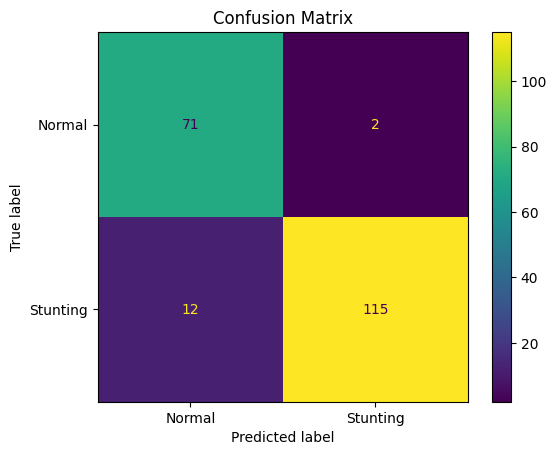

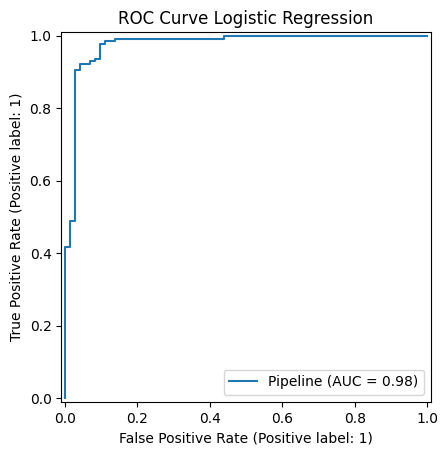

In [24]:
# confusion matrix
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                       display_labels=['Normal', 'Stunting']
                       ).plot(values_format='d')
plt.title("Confusion Matrix")
plt.show()

# ROC Curve
RocCurveDisplay.from_estimator(clf, x_test, y_test)
plt.title("ROC Curve Logistic Regression")
plt.show()

In [25]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names = ['Tidak Stunting (0)', 'Stunting (1)']))


                    precision    recall  f1-score   support

Tidak Stunting (0)       0.86      0.97      0.91        73
      Stunting (1)       0.98      0.91      0.94       127

          accuracy                           0.93       200
         macro avg       0.92      0.94      0.93       200
      weighted avg       0.94      0.93      0.93       200



In [26]:

from sklearn.model_selection import cross_val_score

# lakukan cross validation (cv=5 berarti 5-fold)
scores = cross_val_score(clf, x, y, cv=5)

# tampilkan hasil
print("Skor tiap fold:", scores)
print("Rata-rata akuransi:", np.mean(scores))
print("Standar deviasi:", np.std(scores))

Skor tiap fold: [0.775 0.915 0.955 0.945 0.94 ]
Rata-rata akuransi: 0.9059999999999999
Standar deviasi: 0.06681317235396023


In [27]:

# ambil nama fitur dan koefisien
feat_names = feature_num + feature_bin
coefs = clf.named_steps['model'].coef_[0]
odds = np.exp(coefs)

coef_df = pd.DataFrame({
    'Fitur': feat_names,
    'Koefisien (log-odds)': coefs,
    'Odds Ratio (e^coef)': odds
}).sort_values('Odds Ratio (e^coef)', ascending=False)
display(coef_df)


,Fitur,Koefisien (log-odds),Odds Ratio (e^coef)
2,Penghasilan,4.523667,92.172995
1,Memiliki_Mobil,0.060514,1.062382
0,Usia,-0.048686,0.952480
3,Kelamin_bin,-1.141698,0.319276


In [30]:
# contoh data baru untuk prediksi (sesuai dengan fitur yang digunakan saat pelatihan)
data_baru = pd.DataFrame({
    'Usia': [35, 50],
    'Memiliki_Mobil': [1, 2],
    'Penghasilan': [300, 150],
    'Status': [1, 2],  # Example Status values
    'Kelamin_bin': [0, 1] # 0=perempuan, 1=laki-laki (sesuai mapping sebelumnya)
})
pred = clf.predict(data_baru)
prob = clf.predict_proba(data_baru) [:,1]

hasil = data_baru.copy()
hasil['Prob_Beli_Mobil'] = prob
hasil['Pred (0=Tidak, 1=Ya)'] = pred
display(hasil)

,Usia,Memiliki_Mobil,Penghasilan,Status,Kelamin_bin,Prob_Beli_Mobil,"Pred (0=Tidak, 1=Ya)"
0,35,1,300,1,0,0.979518,1
1,50,2,150,2,1,0.011849,0
